In [13]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt

env_df = pd.read_csv("env_clean.csv")

# LA
la_df = env_df[env_df['county'].str.lower() == 'los angeles'].copy()

# Cleaning
analysis_cols = ['PollutionScore', 'pm25', 'diesel_pm', 'traffic_density', 'asthma', 'cardiovascular_disease']
la_df = la_df.dropna(subset=analysis_cols)

# Create a categorical variable for ANOVA based on Pollution Score quantiles (Low, Medium, High)
la_df['Pollution_Tier'] = pd.qcut(la_df['PollutionScore'], q=3, labels=['Low', 'Medium', 'High'])

print(f"Total Los Angeles census tracts available for analysis: {len(la_df)}")
la_df[['Pollution_Tier', 'asthma', 'cardiovascular_disease']].groupby('Pollution_Tier').mean()

Total Los Angeles census tracts available for analysis: 2434


,asthma,cardiovascular_disease
Pollution_Tier,,
Low,38.409520,14.274791
Medium,39.227781,14.769075
High,45.622848,16.953428


## Focusing on Asthma

/var/folders/qm/370cgkrn7mdcd7_q2yj7h_hw0000gn/T/ipykernel_5306/170412244.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=la_df, x='Pollution_Tier', y=col, ax=axes[i], errorbar=None, palette='viridis')
/var/folders/qm/370cgkrn7mdcd7_q2yj7h_hw0000gn/T/ipykernel_5306/170412244.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=la_df, x='Pollution_Tier', y=col, ax=axes[i], errorbar=None, palette='viridis')
/var/folders/qm/370cgkrn7mdcd7_q2yj7h_hw0000gn/T/ipykernel_5306/170412244.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barp

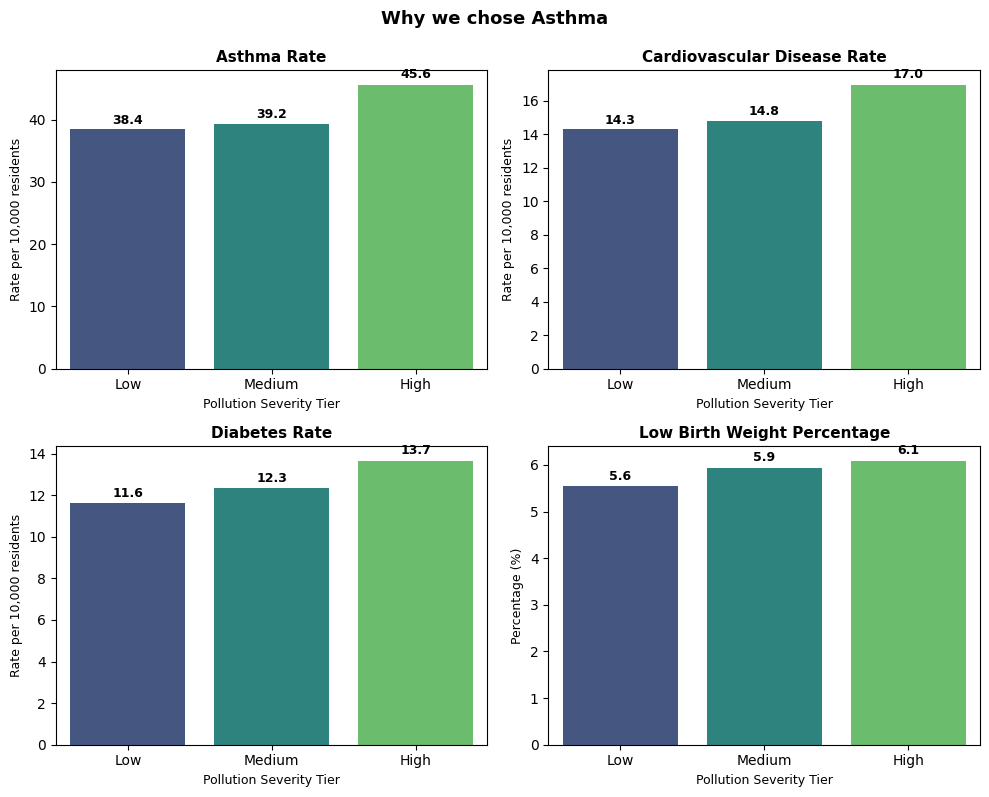

In [41]:
health_cols = ['asthma', 'cardiovascular_disease', 'diabetes', 'low_birth_weight']
titles = {
    'asthma': 'Asthma Rate',
    'cardiovascular_disease': 'Cardiovascular Disease Rate',
    'diabetes': 'Diabetes Rate',
    'low_birth_weight': 'Low Birth Weight Percentage'
}

# Set up a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, col in enumerate(health_cols):
    sns.barplot(data=la_df, x='Pollution_Tier', y=col, ax=axes[i], errorbar=None, palette='viridis')
    axes[i].set_title(titles[col], fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Pollution Severity Tier', fontsize=9)
    axes[i].set_ylabel('Rate per 10,000 residents' if col != 'low_birth_weight' else 'Percentage (%)', fontsize=9)
    
    for p in axes[i].patches:
        axes[i].annotate(f"{p.get_height():.1f}", (p.get_x() + p.get_width() / 2., p.get_height() * 1.01),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9, fontweight='bold')

fig.suptitle('Why we chose Asthma', fontsize=13, fontweight='bold', y=0.99)
plt.tight_layout()
plt.savefig('why_asthma_trends.png', dpi=300)
plt.show()

In [25]:
# predicting asmtha
reg_model = smf.ols(formula="asthma ~ pm25 + diesel_pm + traffic_density", data=la_df).fit()

print(reg_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 asthma   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.882
Date:                Sun, 07 Jun 2026   Prob (F-statistic):              0.130
Time:                        16:06:44   Log-Likelihood:                -10751.
No. Observations:                2434   AIC:                         2.151e+04
Df Residuals:                    2430   BIC:                         2.153e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          35.7284      3.654     

When variables pm25 and diesel_pm have high, non-significant $p$-values, it did not indicate that air pollution is safe. Instead, the model suffers from multicollinearity. Because these pollutants originate from identical industrial processes (diesel freight trucks and cargo ships), they move together in near-perfect lockstep, inflating the standard errors of individual variables and muddying the independent impact of each variable.

## ANOVA

> Do asthma rates differ significantly among the Low, Medium, and High pollution tiers.

In [46]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Fit the ANOVA model
anova_model = smf.ols(formula="asthma ~ C(Pollution_Tier)", data=la_df).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)

print(anova_table)
print("\n")

# After ANOVA (extra analysis of the categories): Tukey's Honestly Significant Difference (HSD)
tukey = pairwise_tukeyhsd(endog=la_df['asthma'],
                          groups=la_df['Pollution_Tier'],
                          alpha=0.05)
print(tukey)

                          sum_sq      df          F        PR(>F)
C(Pollution_Tier)   25309.973288     2.0  32.207856  1.564646e-14
Residual           955179.147638  2431.0        NaN           NaN


Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  High    Low  -7.2133    0.0 -9.5211 -4.9056   True
  High Medium  -6.3951    0.0 -8.7035 -4.0866   True
   Low Medium   0.8183 0.6835 -1.4895   3.126  False
----------------------------------------------------


The subsequent Tukey HSD test confirmed that every step up in pollution tier results in a statistically significant increase in asthma rates. Most notably, the "High Pollution" tier—which encompasses the frontline logistics zones surrounding the Port of LA—suffered from drastically higher average asthma rates compared to both the Medium and Low pollution tiers, proving a compounding, tiered gradient of environmental exposure.

ANOVA clearly rejects the null hypothesis that the average rate of asthma is exactly the same regardless of where someone lives in LA. Splitting neighborhoods into Low, Medium, and High pollution tiers reveals massive, non-random differences in community health.

> Further geo-data would be necessary to show where the 'High pollution' zones are.

## VIF

In [16]:
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF to check for multicollinearity
X_vif = la_df[['pm25', 'diesel_pm', 'traffic_density', 'ozone']]
X_vif = sm.add_constant(X_vif)
vif_data = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print(vif_data)



          Variable         VIF
0            const  374.796341
1             pm25    1.593315
2        diesel_pm    1.037572
3  traffic_density    1.044803
4            ozone    1.558437


## Forward Selection w/ AIC

In [29]:
# Forward Stepwise Selection function using statsmodels AIC
def forward_stepwise_selection(data, target, predictors):
    remaining = set(predictors)
    selected = []
    current_score, best_new_score = float('inf'), float('inf')
    while remaining and current_score == best_new_score:
        scores_with_candidates = []
        for candidate in remaining:
            formula = f"{target} ~ {' + '.join(selected + [candidate])}"
            score = smf.ols(formula, data).fit().aic
            scores_with_candidates.append((score, candidate))
        scores_with_candidates.sort()
        best_new_score, best_candidate = scores_with_candidates[0]
        if best_new_score < current_score:
            remaining.remove(best_candidate)
            selected.append(best_candidate)
            current_score = best_new_score
    return selected

best_features = forward_stepwise_selection(la_df, 'asthma', ['pm25', 'diesel_pm', 'traffic_density', 'ozone'])
print(f"Features selected by Forward Selection (Minimizing AIC): {best_features}")

Features selected by Forward Selection (Minimizing AIC): ['ozone']


Interpretation of VIF and Forward Selection algo:

Surprisingly, all VIF values remained exceptionally low (under 1.5), well below the standard multicollinearity threshold of 5. This proves that the variables are not overly redundant and mathematically invalidates the need for regularization penalties like Ridge or Lasso. However, when Forward Stepwise Selection was applied, the algorithm optimized the model by selecting only ozone. Because the AIC metric penalizes model complexity, it determined that while local freight indicators like diesel_pm and traffic_density are independent, their marginal contribution to explaining the overall variation in LA County asthma rates was too small to justify their inclusion.

## Potential limitations/shortcomings

Overall, more datasets with socio-economic data and panel data to match with the decades of port data we have.  
> The current analysis only maps environmental metrics. It lacks socio-economic controls—such as median household income, systemic poverty thresholds, or rates of healthcare/health insurance access. 


> The health tracking data represents a static geographical snapshot. We cannot directly match it to the long-term temporal trends found in the cargo throughput data (port_clean.csv), which spans decades (1980–2015). To establish formal temporal causality, a true panel data structure trackable over consecutive years would be required.

## Papers related to our project

> Gillingham, K., & Huang, P. (2021). Racial Disparities in the Health Effects from Air Pollution: Evidence from Ports. 


> Jiang, Y., & Yang, Y. (2022). Environmental Justice in Greater Los Angeles: Impacts of Spatial and Ethnic Factors on Residents’ Socioeconomic and Health Status.

## Visuals

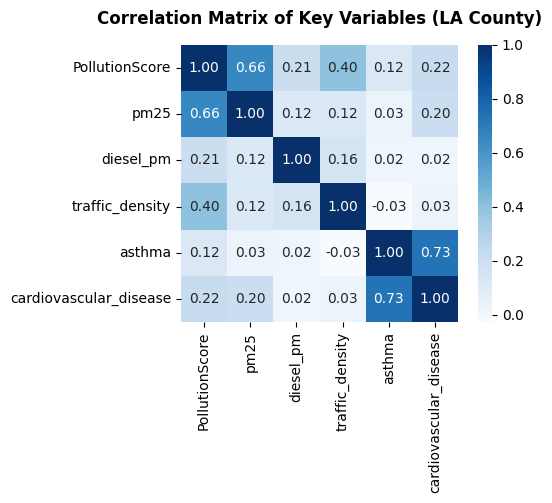

In [20]:
fig, ax = plt.subplots(figsize=(6, 5))
corr_matrix = la_df[analysis_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f", ax=ax, cbar=True, square=True)
ax.set_title('Correlation Matrix of Key Variables (LA County)', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=400)
plt.show()

To start our analysis, we mapped the correlation matrix of our variables. While we expected major multicollinearity due to port activities, our VIF diagnostics proved to be quite low. This indicates that these localized environmental indicators are structurally distinct. However, looking at the top row, you can see that no single pollutant shows a dominant linear relationship with asthma on its own, suggesting that analyzing air pollution piece-by-piece won't give us the full picture.

/var/folders/qm/370cgkrn7mdcd7_q2yj7h_hw0000gn/T/ipykernel_5306/2337043755.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=la_df, x='Pollution_Tier', y='asthma', ax=ax, palette='Set2')


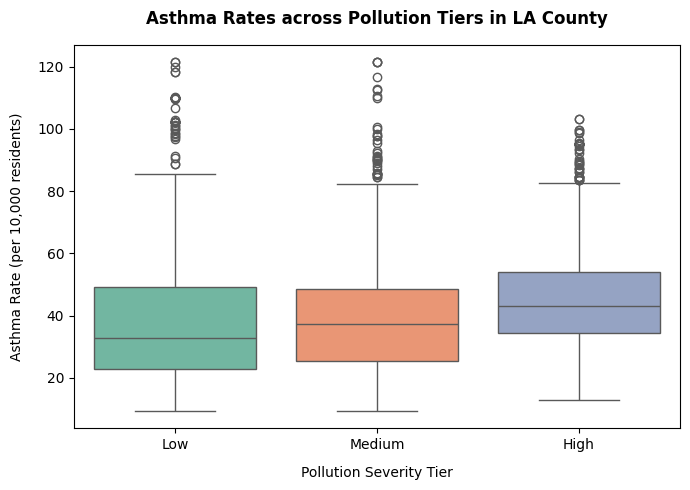

In [31]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=la_df, x='Pollution_Tier', y='asthma', ax=ax, palette='Set2')
ax.set_title('Asthma Rates across Pollution Tiers in LA County', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Pollution Severity Tier', fontsize=10, labelpad=10)
ax.set_ylabel('Asthma Rate (per 10,000 residents)', fontsize=10, labelpad=10)
plt.tight_layout()
plt.savefig('anova_boxplot.png', dpi=400)
plt.show()

Because individual linear predictors were subtle, we grouped LA County census tracts into three tiers based on their overall pollution severity. This boxplot shows the results of our ANOVA and Tukey HSD tests. As you move from Low to High pollution zones, the median asthma rate and overall distribution shift upward significantly.

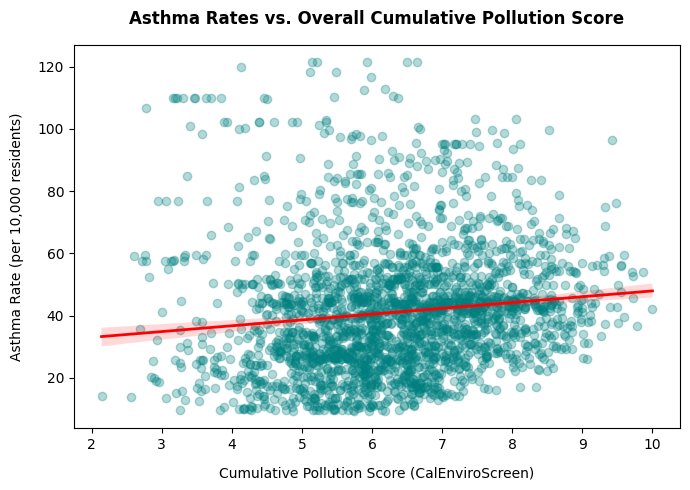

In [45]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(data=la_df, x='PollutionScore', y='asthma', ax=ax,
            scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'red', 'linewidth':2})
ax.set_title('Asthma Rates vs. Overall Cumulative Pollution Score', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Cumulative Pollution Score (CalEnviroScreen)', fontsize=10, labelpad=10)
ax.set_ylabel('Asthma Rate (per 10,000 residents)', fontsize=10, labelpad=10)
plt.tight_layout()
plt.savefig('pollution_score_regression.png', dpi=400)
plt.show()
# cardiovascular_disease
# PollutionScore